In [1]:
from langgraph.graph import StateGraph, START, END 

In [27]:
import random
from typing import TypedDict, List

In [28]:
class GameState(TypedDict):
    player_name:str
    target:int
    guesses: List[int]
    attempts:int
    lower_bound:int
    upper_bound:int
    hint: str
    

In [37]:
def guess_node(state:GameState)->GameState:
    "guessing a number based on current state"
    low = state['lower_bound']
    high = state['upper_bound']
    
    if not state['guesses']:
        current_guess = 0
    else:
        current_guess  = state['guesses'][-1] +1
    
    state['guesses'].append(current_guess)
    state['attempts'] +=1
    
    if current_guess == state['target']:
        state['hint'] = 'correct'
    else:
        state['hint'] = 'too low'
    return state

In [38]:
def should_continue(state:GameState):
    if state['hint'] == 'correct':
        return 'exit'
    if state['attempts'] >= 7:
        return 'exit'

    return 'loop'

In [39]:
workflow = StateGraph(GameState)
workflow.add_node('guess',guess_node)
workflow.set_entry_point("guess")


In [40]:
workflow.add_conditional_edges(
    'guess',
    should_continue,{
        'loop':'guess',
        'exit':END
    }
)
app = workflow.compile()

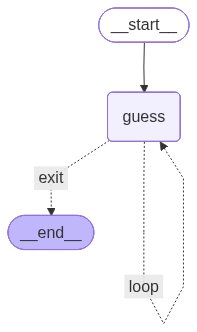

In [41]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [42]:
print(app.invoke({
    "player_name": "Brian",
    "target": 14,
    "guesses": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20,
    "hint": ""
}))

{'player_name': 'Brian', 'target': 14, 'guesses': [0, 1, 2, 3, 4, 5, 6], 'attempts': 7, 'lower_bound': 1, 'upper_bound': 20, 'hint': 'too low'}
